In this notebook Seamese network model with contrastive loss for handwriting author verification trained. As backbpn ResNet50 used with freezed parameters.

First, we import our dataset. For training we use handwriting examples from 4 classic datasets: IAM, CEDAR, Bengali и Hindi

In [22]:
#importing dataset
!pip install -q gdown

file_id = "1A-MZ6zw_0uJQPuwj9GFeqwOPz2fqKOn_"
output_name = "all_data_3.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1A-MZ6zw_0uJQPuwj9GFeqwOPz2fqKOn_
From (redirected): https://drive.google.com/uc?id=1A-MZ6zw_0uJQPuwj9GFeqwOPz2fqKOn_&confirm=t&uuid=54123d0a-7952-4899-86de-e7ff54798aea
To: /content/all_data_3.zip
100% 1.76G/1.76G [00:27<00:00, 64.9MB/s]


In [23]:
import zipfile
import os

with zipfile.ZipFile("all_data_3.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['all_data_3']

In [24]:
DATA_ROOT = "/kaggle/working/all_data_3"

Importing required modules

In [1]:
!pip install timm

In [2]:
!pip install torchvision

In [20]:
val_dataset_file="1aJ87RzaTUVQcC8CIT_7xiPWQGFn0pAOx"
output_name = "val_triplet.pkl"

!gdown --id {val_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1aJ87RzaTUVQcC8CIT_7xiPWQGFn0pAOx
To: /content/val_triplet.pkl
100% 178k/178k [00:00<00:00, 66.8MB/s]


In [3]:
test_dataset_file="17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF"
output_name = "test_pairs.pkl"

!gdown --id {test_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF
To: /content/test_pairs.pkl
100% 95.7k/95.7k [00:00<00:00, 65.4MB/s]


In [4]:
DATA_ROOT_val_pairs = "/kaggle/working/val_triplet.pkl"
DATA_ROOT_test_pairs = "/kaggle/working/test_pairs.pkl"

In [5]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, LinearLR, CosineAnnealingLR, SequentialLR
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import pickle

from torchvision.models import resnet18, ResNet18_Weights

Fixing seeds

In [6]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Let's create class Pairs_Dataset for our data.
The dataset takes random pairs and create either positive (one author/two genuine signatures pf one author) or negative pair (two different authors/genuine and forgery of the sameauthor). The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [9]:
class TripletDataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 authors_list=None, iam_ratio=0.5):
        """
        Dataset for Triplet Loss.
        Supports IAM (handwriting lines), CEDAR, Bengali, Hindi (signatures with forgeries).

        Returns triplets (anchor, positive, negative) where:
        - IAM: anchor + positive = same author, negative = different author
        - Signature datasets: anchor + positive = two genuine of same author, negative = forgery of same author

        Args:
            root: Root directory containing 'iam', 'cedar', 'bengali', 'hindi' folders
            transform: Image transformations
            size: Number of triplets per epoch
            authors_list: List of author IDs to include (for train/val split)
            iam_ratio: Probability of sampling from IAM (0.5 = 50% IAM)
        """
        self.transform = transform
        self.size = size
        self.iam_ratio = iam_ratio

        # Data structures
        self.iam_data = {}
        self.cedar_original = {}
        self.cedar_forgery = {}
        self.bengali_original = {}
        self.bengali_forgery = {}
        self.hindi_original = {}
        self.hindi_forgery = {}

        # === Scan IAM folder ===
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        #Scan CEDAR folder
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            cedar_original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(cedar_original_path):
                for author_id in os.listdir(cedar_original_path):
                    author_path = os.path.join(cedar_original_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            cedar_forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(cedar_forgery_path):
                for author_id in os.listdir(cedar_forgery_path):
                    author_path = os.path.join(cedar_forgery_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        #Scan Bengali folder
        bengali_path = os.path.join(root, 'bengali')
        if os.path.exists(bengali_path):
            for author_id in os.listdir(bengali_path):
                author_path = os.path.join(bengali_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_forgery[author_id] = valid_images

        #Scan Hindi folder
        hindi_path = os.path.join(root, 'hindi')
        if os.path.exists(hindi_path):
            for author_id in os.listdir(hindi_path):
                author_path = os.path.join(hindi_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_forgery[author_id] = valid_images

        # Filter by authors_list if provided
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
            self.bengali_original = {k: v for k, v in self.bengali_original.items() if k in author_set}
            self.bengali_forgery = {k: v for k, v in self.bengali_forgery.items() if k in author_set}
            self.hindi_original = {k: v for k, v in self.hindi_original.items() if k in author_set}
            self.hindi_forgery = {k: v for k, v in self.hindi_forgery.items() if k in author_set}

        # Build author lists
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.iam_all_authors = list(self.iam_data.keys())

        def build_signature_lists(original_dict, forgery_dict):
            authors_with_original = [a for a, imgs in original_dict.items() if len(imgs) >= 2]
            authors_with_forgery = [a for a in original_dict.keys()
                                     if a in forgery_dict
                                     and len(original_dict[a]) >= 1
                                     and len(forgery_dict[a]) >= 1]
            all_authors = list(original_dict.keys())
            return authors_with_original, authors_with_forgery, all_authors

        self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors = build_signature_lists(self.cedar_original, self.cedar_forgery)
        self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors = build_signature_lists(self.bengali_original, self.bengali_forgery)
        self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors = build_signature_lists(self.hindi_original, self.hindi_forgery)

        # Combine signature datasets
        self.signature_datasets = []
        if self.cedar_authors or self.cedar_authors_with_forgery:
            self.signature_datasets.append(('cedar', self.cedar_original, self.cedar_forgery,
                                           self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors))
        if self.bengali_authors or self.bengali_authors_with_forgery:
            self.signature_datasets.append(('bengali', self.bengali_original, self.bengali_forgery,
                                           self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors))
        if self.hindi_authors or self.hindi_authors_with_forgery:
            self.signature_datasets.append(('hindi', self.hindi_original, self.hindi_forgery,
                                           self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors))

    def __len__(self):
        return self.size

    def _get_iam_triplet(self):
        """IAM triplet: anchor + positive = same author, negative = different author"""
        if len(self.iam_authors) < 1:
            return None, None, None

        author = random.choice(self.iam_authors)
        images = self.iam_data[author]
        if len(images) < 2:
            return None, None, None

        # Anchor and Positive: two different images from same author
        anchor_path, positive_path = random.sample(images, 2)

        # Negative: different author
        other_authors = [a for a in self.iam_all_authors if a != author]
        if not other_authors:
            return None, None, None

        negative_author = random.choice(other_authors)
        negative_path = random.choice(self.iam_data[negative_author])

        return anchor_path, positive_path, negative_path

    def _get_signature_triplet(self, original_dict, forgery_dict, authors_with_forgery):
        """Signature triplet: anchor + positive = two genuines of same author, negative = forgery of same author"""
        if not authors_with_forgery:
            return None, None, None

        author = random.choice(authors_with_forgery)
        original_images = original_dict[author]
        forgery_images = forgery_dict[author]

        if len(original_images) < 2 or not forgery_images:
            return None, None, None

        # Anchor and Positive: two different genuine images
        anchor_path, positive_path = random.sample(original_images, 2)

        # Negative: forgery of the same author
        negative_path = random.choice(forgery_images)

        return anchor_path, positive_path, negative_path

    def __getitem__(self, idx):
        use_iam = random.random() < self.iam_ratio

        anchor_path, positive_path, negative_path = None, None, None

        if use_iam and self.iam_authors:
            anchor_path, positive_path, negative_path= self._get_iam_triplet()

        if anchor_path is None and self.signature_datasets:
            dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
            anchor_path, positive_path, negative_path = self._get_signature_triplet(original_dict, forgery_dict, authors_with_forgery)

        if anchor_path is None:
            # Fallback: try IAM
            if self.iam_authors:
                anchor_path, positive_path, negative_path = self._get_iam_triplet()
            elif self.signature_datasets:
                dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
                anchor_path, positive_path, negative_path = self._get_signature_triplet(original_dict, forgery_dict, authors_with_forgery)

        # Load images
        anchor = Image.open(anchor_path).convert('L')
        positive = Image.open(positive_path).convert('L')
        negative = Image.open(negative_path).convert('L')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

Now let's generate authors for train, val, and test in ration 70/15/15 so that they do not intersect. For further work the authors' sets are fixed and the code will be commented

In [12]:
# iam_path = os.path.join(DATA_ROOT, 'iam')
# cedar_path = os.path.join(DATA_ROOT, 'cedar', 'original')
# bengali_path = os.path.join(DATA_ROOT, 'bengali')
# hindi_path = os.path.join(DATA_ROOT, 'hindi')

# # Get authors from each dataset
# iam_authors = os.listdir(iam_path) if os.path.exists(iam_path) else []
# cedar_authors = os.listdir(cedar_path) if os.path.exists(cedar_path) else []
# bengali_authors = os.listdir(bengali_path) if os.path.exists(bengali_path) else []
# hindi_authors = os.listdir(hindi_path) if os.path.exists(hindi_path) else []

# # Combine all authors
# all_authors = list(set(iam_authors + cedar_authors + bengali_authors + hindi_authors))

# print(f"IAM authors: {len(iam_authors)}")
# print(f"CEDAR authors: {len(cedar_authors)}")
# print(f"Bengali authors: {len(bengali_authors)}")
# print(f"Hindi authors: {len(hindi_authors)}")
# print(f"Total unique authors: {len(all_authors)}")

# # Shuffle and split
# random.shuffle(all_authors)

# # Split: 70% train, 15% val, 15% test
# train_split = int(len(all_authors) * 0.7)
# val_split = int(len(all_authors) * 0.85)

# train_authors = all_authors[:train_split]
# val_authors = all_authors[train_split:val_split]
# test_authors = all_authors[val_split:]

# print(f"\nTrain authors: {len(train_authors)} ({len(train_authors)/len(all_authors)*100:.1f}%)")
# print(f"Val authors: {len(val_authors)} ({len(val_authors)/len(all_authors)*100:.1f}%)")
# print(f"Test authors: {len(test_authors)} ({len(test_authors)/len(all_authors)*100:.1f}%)")

# # Optional: Check distribution per dataset
# print("\nDistribution per dataset")
# for dataset_name, authors_list in [('IAM', iam_authors), ('CEDAR', cedar_authors),
#                                     ('Bengali', bengali_authors), ('Hindi', hindi_authors)]:
#     train_count = len([a for a in authors_list if a in train_authors])
#     val_count = len([a for a in authors_list if a in val_authors])
#     test_count = len([a for a in authors_list if a in test_authors])
#     print(f"{dataset_name}: train={train_count}, val={val_count}, test={test_count}")

In [10]:
train_authors=['353', '662', '546', '181', '126', '104', '15', '72', '629', '094', '10', '139', '090', '636', '160', '092', '136', '328', '190', '20', '392', '652',
               '5', '405', '378', '236', '650', '573', '162', '349', '515', '59', '128', '421', '48', '14', '3', '262', '454', '670', '281', '543', '435', '632', '393',
               '192', '594', '237', '270', '250', '153', '320', '6', '531', '418', '399', '460', '603', '027', '598', '276', '083', '216', '391', '131', '2', '496', '53',
               '618', '093', '318', '214', '189', '110', '425', '389', '420', '401', '32', '562', '170', '93', '609', '616', '357', '597', '80', '626', '332', '119', '060',
               '487', '025', '547', '390', '513', '147', '072', '553', '183', '623', '615', '500', '198', '011', '174', '647', '664', '278', '445', '290', '210', '272',
               '448', '503', '534', '69', '88', '68', '120', '24', '464', '398', '568', '070', '610', '628', '591', '31', '529', '215', '149', '138', '118', '451', '572',
               '17', '339', '049', '25', '60', '26', '243', '054', '032', '586', '471', '377', '342', '87', '58', '620', '179', '89', '109', '304', '034', '365', '373',
               '363', '169', '071', '49', '579', '382', '444', '412', '485', '310', '473', '619', '084', '518', '535', '144', '542', '280', '145', '520', '156', '099',
               '576', '570', '589', '059', '595', '208', '361', '307', '558', '101', '67', '030', '38', '115', '19', '371', '340', '567', '319', '352', '274', '530',
               '102', '259', '555', '525', '462', '226', '27', '539', '041', '607', '508', '344', '182', '79', '288', '085', '095', '239', '267', '584', '92', '639',
               '410', '70', '184', '121', '492', '114', '509', '053', '334', '246', '490', '449', '255', '440', '185', '580', '294', '477', '495', '436', '291', '641',
               '33', '35', '21', '089', '103', '289', '370', '221', '466', '242', '076', '423', '379', '020', '008', '224', '019', '248', '98', '067', '483', '37', '663',
               '064', '582', '086', '031', '23', '563', '611', '305', '96', '472', '283', '043', '414', '141', '34', '151', '065', '621', '55', '91', '260', '231', '048',
               '478', '499', '606', '056', '354', '229', '045', '81', '096', '343', '408', '264', '155', '596', '253', '461', '235', '042', '73', '347', '482', '475',
               '386', '197', '394', '431', '65', '634', '416', '90', '36', '303', '122', '018', '517', '668', '252', '097', '228', '107', '413', '082', '556', '203',
               '494', '285', '028', '191', '592', '256', '578', '171', '002', '188', '526', '367', '116', '522', '234', '71', '30', '035', '364', '268', '327', '484',
               '146', '312', '533', '4', '046', '209', '433', '86', '402', '350', '640', '428', '453', '279', '536', '441', '037', '614', '47', '296', '159', '315', '062',
               '000', '407', '549', '080', '335', '079', '504', '659', '419', '117', '540', '081', '452', '351', '521', '384', '051', '648', '524', '036', '411', '75',
               '645', '325', '559', '211', '583', '527', '1', '502', '447', '7', '193', '565', '99', '152', '551', '608', '403', '195', '298', '006', '004', '077',
               '187', '301', '491', '366', '130', '538', '206', '324', '175', '098', '247', '180', '222', '251', '28', '63', '474', '671', '545', '088', '052', '388',
               '257', '123', '172', '486', '83', '554', '41', '417', '430', '660', '023', '56', '380', '40', '227', '566', '026', '219', '481', '575', '309', '489', '638',
               '148', '45', '258', '249', '200', '356', '331', '263', '232', '630', '063', '164', '544', '168', '359', '443', '047', '186', '85', '470', '336', '176',
               '078', '651', '196', '577', '455', '012', '666', '571', '317', '376', '429', '655', '314', '52', '600', '058', '212', '016', '022', '217', '94', '106',
               '44', '244', '77', '199', '8', '329', '22', '519', '561', '643', '64', '137', '501', '493']
val_authors=['456', '9', '426', '97', '322', '133', '13', '021', '157', '355', '166', '375', '627', '345', '605', '140', '135', '161', '163', '593', '476', '84', '225',
             '223', '62', '213', '512', '266', '537', '446', '100', '346', '422', '233', '613', '167', '261', '360', '127', '633', '292', '442', '341', '564', '468',
             '654', '467', '302', '330', '220', '465', '458', '18', '299', '326', '286', '014', '528', '635', '007', '569', '548', '333', '57', '207', '581', '039',
             '50', '338', '439', '205', '54', '552', '173', '348', '644', '488', '665', '362', '498', '409', '637', '587', '075', '300', '108', '642', '74', '400',
             '76', '074', '125', '51', '091', '017', '295', '245', '624', '142', '383', '585', '457', '230', '040', '497', '073', '432', '369', '275', '506', '201',
             '241', '129', '218']
test_authors=['43', '134', '516', '055', '204', '313', '523', '068', '404', '372', '601', '395', '469', '617', '009', '254', '588', '194', '337', '178', '511', '29',
              '015', '82', '287', '124', '599', '112', '39', '541', '293', '010', '143', '625', '132', '95', '158', '649', '622', '316', '282', '667', '532', '321',
              '177', '013', '505', '297', '631', '42', '658', '66', '368', '202', '510', '590', '165', '459', '154', '434', '61', '005', '397', '105', '602', '265',
              '46', '396', '387', '450', '323', '001', '087', '240', '113', '066', '604', '044', '061', '550', '463', '653', '033', '273', '669', '514', '150', '024',
              '424', '479', '069', '16', '574', '308', '238', '038', '415', '560', '385', '557', '277', '480', '612', '661', '111', '12', '427', '78', '050', '003',
              '269', '11', '406', '029']


Let's create transformations. For train we use rotation and random affine augmentations. For the model images 224*224 used

In [7]:
train_transform = T.Compose([
    T.Resize((224, 224)),  #use 240*240 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

Now we create train dataset. The dataset is nor fixed, at each iteration random pairs are created

In [25]:
train_dataset = TripletDataset(
    root=DATA_ROOT,
    transform=train_transform,
    size=5000,
    authors_list=train_authors
)


For val and test sets we fix the dataset. For the first time we generate them useing Pairs_Dataset above. The the labels and paths to images fixed and saveed to be reused for other models. To reuse we create SavedPairsDataset to recreate datasets from saved pkl.files.

In [8]:
class SavedTestPairsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

# # Создание и сохранение
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка

test_dataset = SavedTestPairsDataset('test_pairs.pkl', transform=test_transform)

In [18]:
class SavedTripletDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, img3_path = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')
        img3 = Image.open(img3_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
            img3 = self.transform(img3)

        return img1, img2, img3

In [22]:


# # Создание и сохранение
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка
val_dataset = SavedTripletDataset('val_triplet.pkl', transform=val_transform)

In [ ]:
val_dataset[0]

(tensor([[[1.9235, 1.9235, 1.9407,  ..., 1.9749, 1.9407, 1.9578],
          [1.8722, 1.8893, 1.9235,  ..., 2.0092, 1.9749, 1.9578],
          [1.9064, 1.9235, 1.9235,  ..., 1.9920, 1.9578, 1.9407],
          ...,
          [1.9578, 1.9578, 1.9578,  ..., 1.9749, 1.9920, 2.0434],
          [1.9407, 1.9407, 1.9578,  ..., 1.9749, 1.9920, 1.9920],
          [1.9920, 1.9578, 1.9749,  ..., 1.9749, 1.9749, 2.0092]]]),
 tensor([[[2.2489, 2.2318, 2.2318,  ..., 2.2318, 2.2318, 2.2147],
          [2.2489, 2.2318, 2.2318,  ..., 2.2489, 2.2318, 2.2489],
          [2.2318, 2.2147, 2.2147,  ..., 2.2318, 2.2318, 2.2318],
          ...,
          [2.2489, 2.2147, 2.2318,  ..., 2.2318, 2.2318, 2.2318],
          [2.2318, 2.2318, 2.2318,  ..., 2.2318, 2.2489, 2.2489],
          [2.1975, 2.1975, 2.1975,  ..., 2.2318, 2.2489, 2.2318]]]),
 0)

Let's look at the example of data. The val and test datasets are fixed, the train dataset is created on the fly

Label: 0
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


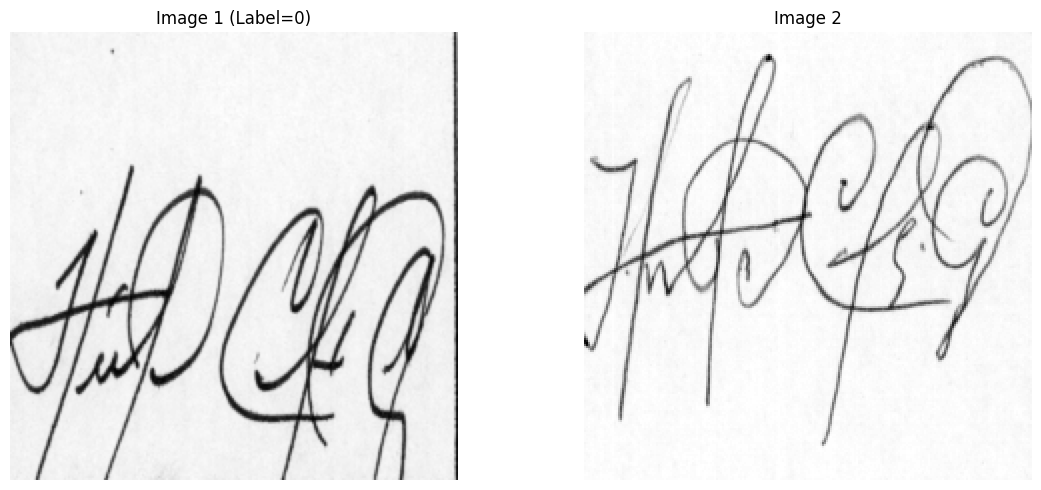

/kaggle/working/all_data_3/cedar/original/017/original_17_24.png
/kaggle/working/all_data_3/cedar/forgery/017/forgeries_17_9.png


In [ ]:
img1, img2, label, p1, p2 = val_dataset[29]

print(f"Label: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

print(p1)
print(p2)

Let's make sure that the datasets are balanced

In [ ]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

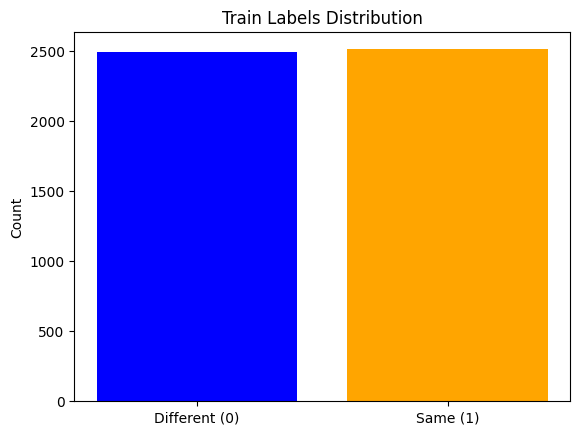

In [ ]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [ ]:
labels_val=[]

for i in range(len(val_dataset)):
  labels_val.append(val_dataset[i][2])

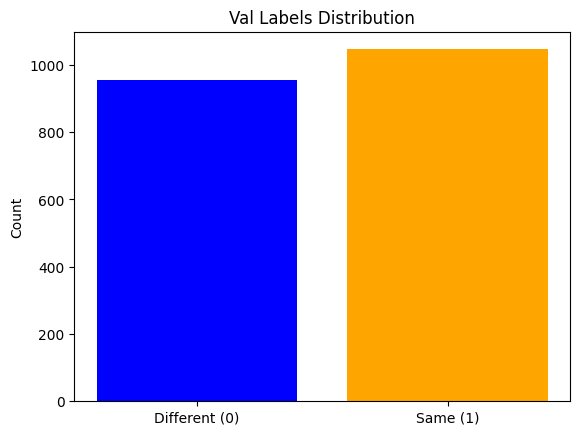

In [ ]:
counts = [labels_val.count(0), labels_val.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Val Labels Distribution')
plt.show()

In [ ]:
labels_test=[]

for i in range(len(test_dataset)):
  labels_test.append(test_dataset[i][2])

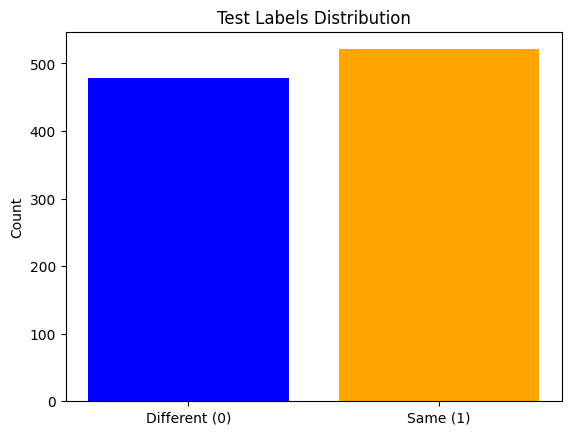

In [ ]:
counts = [labels_test.count(0), labels_test.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Test Labels Distribution')
plt.show()

There are very little imbalance which is insignification for our task

Now we create dataloaders

In [23]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [12]:
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class for our model. The class has freeze_mode parameter (aggressive or moderate), in aggressive mode we freeze all layer except for the last one (layer4), in moderate except for 2 lasts (layer3 and 4layers).For training we use Contrastive loss. To calculate metrics distance between embeddings used, threshold is set using iteration.

In [13]:


class SiameseNetwork(nn.Module):
    def __init__(self, embedding_size=256, freeze_mode="aggressive"):
        super(SiameseNetwork, self).__init__()

        # Load pretrained ResNet-50
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Adapt first layer for single channel
        original_conv1 = backbone.conv1
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        # Remove final FC layer
        self.resnet = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze layers based on mode
        if freeze_mode == "aggressive":
            # Freeze all layers
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer4 (index 7) and conv1 (index 0)
            for name, param in self.resnet.named_parameters():
                if name.startswith('7.'):  # layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "moderate":
            # Freeze all layers first
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer3 (index 6) and layer4 (index 7)
            for name, param in self.resnet.named_parameters():
                if name.startswith('6.') or name.startswith('7.'):
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "none":
            # All layers trainable
            pass

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        self.embedding_size = embedding_size

        # Print statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Freeze mode: {freeze_mode}")
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.resnet(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, anchor, positive, negative):
        emb_anchor = self.forward_one(anchor)
        emb_positive = self.forward_one(positive)
        emb_negative = self.forward_one(negative)
        return emb_anchor, emb_positive, emb_negative

Let's create class of contrastive loss, eucledian distance used

Let's create function for training and calculating metrics.


train_model() trains a Siamese network with:

Contrastive Loss (margin=1.0) to pull same-author embeddings together and push different-author embeddings apart.

AdamW optimizer + ReduceLROnPlateau scheduler.

Tracking of training/validation: loss, accuracy (fixed threshold 0.5), ROC-AUC, and EER.

Distances (Euclidean) are computed between embedding pairs, then used for all metrics.

The best model is saved based on highest validation ROC-AUC.

Returns training history for analysis.


calculate_eer() computes the Equal Error Rate from distances and labels, converting distances to similarity scores (negative distances) for ROC calculation, then finds the threshold where FPR and FNR are closest.

The model is trained for 30 epochs, learning rate 0.001, weight decay 0.0001.

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
from tqdm import tqdm
import torch.optim as optim
import torch.nn.functional as F

class TripletLoss(nn.Module):
    """Triplet Loss using Euclidean distance"""
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = torch.norm(anchor - positive, p=2, dim=1)
        neg_dist = torch.norm(anchor - negative, p=2, dim=1)
        losses = F.relu(pos_dist - neg_dist + self.margin)
        return losses.mean()


def calculate_eer(labels, distances):
    """
    Calculate Equal Error Rate (EER) from distances

    Args:
        labels: true labels (0 or 1, where 1 = same author, 0 = different authors)
        distances: Euclidean distances between embeddings (smaller = more similar)

    Returns:
        eer: Equal Error Rate
    """
    scores = -np.array(distances)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer


def train_triplet_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    margin=1.0,
    device=None,
    save_path='best_triplet_model.pth',
    weight_decay=0.01
):
    """Training Siamese network with Triplet Loss"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    # Optimizer and scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, threshold=0.01
    )

    # Triplet Loss
    triplet_loss = TripletLoss(margin=margin)

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'val_roc_auc': [], 'val_eer': [],
        'train_roc_auc': [], 'train_eer': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # ========== TRAINING ==========
        model.train()
        train_loss = 0.0
        train_labels = []
        train_distances = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            # Forward pass - returns three embeddings
            emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

            # Compute loss
            loss = triplet_loss(emb_anchor, emb_positive, emb_negative)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Compute distances for metrics
            pos_dist = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
            neg_dist = torch.norm(emb_anchor - emb_negative, p=2, dim=1)

            # Store for metrics: positive pairs (label=1) and negative pairs (label=0)
            train_labels.extend([1] * len(pos_dist))
            train_labels.extend([0] * len(neg_dist))
            train_distances.extend(pos_dist.detach().cpu().numpy())
            train_distances.extend(neg_dist.detach().cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss_avg = train_loss / len(train_loader)

        # Calculate training metrics
        train_roc_auc = roc_auc_score(train_labels, [-d for d in train_distances]) if len(set(train_labels)) > 1 else 0.5
        train_eer = calculate_eer(train_labels, train_distances)

        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0.0
        val_labels = []
        val_distances = []

        with torch.no_grad():
            for anchor, positive, negative in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

                # Compute loss
                loss = triplet_loss(emb_anchor, emb_positive, emb_negative)
                val_loss += loss.item()

                # Compute distances for metrics
                pos_dist = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
                neg_dist = torch.norm(emb_anchor - emb_negative, p=2, dim=1)

                val_labels.extend([1] * len(pos_dist))
                val_labels.extend([0] * len(neg_dist))
                val_distances.extend(pos_dist.cpu().numpy())
                val_distances.extend(neg_dist.cpu().numpy())

        val_loss_avg = val_loss / len(val_loader)

        # Calculate validation metrics
        val_roc_auc = roc_auc_score(val_labels, [-d for d in val_distances]) if len(set(val_labels)) > 1 else 0.5
        val_eer = calculate_eer(val_labels, val_distances)

        # Update scheduler
        scheduler.step(val_loss_avg)

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_roc_auc'].append(train_roc_auc)
        history['train_eer'].append(train_eer)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_eer'].append(val_eer)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, ROC-AUC: {train_roc_auc:.4f}, EER: {train_eer:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_roc_auc': val_roc_auc,
                'val_eer': val_eer,
                'margin': margin
            }, save_path)
            print(f"Model saved. ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}")

    return history

Now let's train our model with aggressive freeze_mode

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train

In [27]:
model_agr_freezed = SiameseNetwork(embedding_size=256, freeze_mode=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_agr_freezed = train_triplet_model(
    model=model_agr_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_agr_freezed.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history_agr_freezed['val_roc_auc'])*100:.2f}%")

Freeze mode: None
Total parameters: 25,862,336
Trainable parameters: 25,862,336 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:46<00:00,  5.33it/s]



Epoch 1/30
  Train Loss: 0.7663, ROC-AUC: 0.6544, EER: 0.3975
  Val Loss:   0.7389, ROC-AUC: 0.6722, EER: 0.3912
  LR: 0.001000
Model saved. ROC-AUC: 0.6722, EER: 0.3912


Epoch 2/30 [Val]: 100%|██████████| 250/250 [00:45<00:00,  5.54it/s]



Epoch 2/30
  Train Loss: 0.5714, ROC-AUC: 0.7553, EER: 0.3073
  Val Loss:   0.5041, ROC-AUC: 0.7737, EER: 0.2985
  LR: 0.001000
Model saved. ROC-AUC: 0.7737, EER: 0.2985


...


Epoch 28/30
  Train Loss: 0.0897, ROC-AUC: 0.9850, EER: 0.0498
  Val Loss:   0.4418, ROC-AUC: 0.8825, EER: 0.1977
  LR: 0.000031


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:44<00:00,  5.60it/s]



Epoch 29/30
  Train Loss: 0.0943, ROC-AUC: 0.9844, EER: 0.0526
  Val Loss:   0.4138, ROC-AUC: 0.8921, EER: 0.1803
  LR: 0.000016
Model saved. ROC-AUC: 0.8921, EER: 0.1803


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:44<00:00,  5.64it/s]



Epoch 30/30
  Train Loss: 0.0952, ROC-AUC: 0.9855, EER: 0.0532
  Val Loss:   0.3777, ROC-AUC: 0.8977, EER: 0.1785
  LR: 0.000016
Model saved. ROC-AUC: 0.8977, EER: 0.1785

Best Val ROC-AUC: 89.77%


In [31]:
history_agr_freezed

{'train_loss': [0.7662556956291199,
  0.5713709575414657,
  0.5407531880855561,
  0.5315118616580963,
  0.37276742577552796,
  0.3059592402696609,
  0.23585551028251647,
  0.2334579416155815,
  0.17602110739946367,
  0.1805159014105797,
  0.15732464488744735,
  0.14310295855998992,
  0.13439274886846542,
  0.1378613840341568,
  0.13814026149511338,
  0.11443826466798783,
  0.11164761328697205,
  0.11464171369075775,
  0.11697620692253113,
  0.114064044547081,
  0.10662289081811904,
  0.1200943661570549,
  0.12254565677642822,
  0.09985555635690689,
  0.09804486489295959,
  0.10870651853084565,
  0.10525895237922668,
  0.08965006266832351,
  0.09430079822540283,
  0.09519565418958664],
 'val_loss': [0.7388880400657654,
  0.5041318016350269,
  0.4645125181674957,
  0.5193682620227337,
  0.4517790330052376,
  0.4686967376470566,
  0.8319163423776627,
  0.5280872248411178,
  0.46064178335666656,
  0.5183437593281269,
  0.5299738014936447,
  0.4512997094988823,
  0.5596583952903748,
  0.444

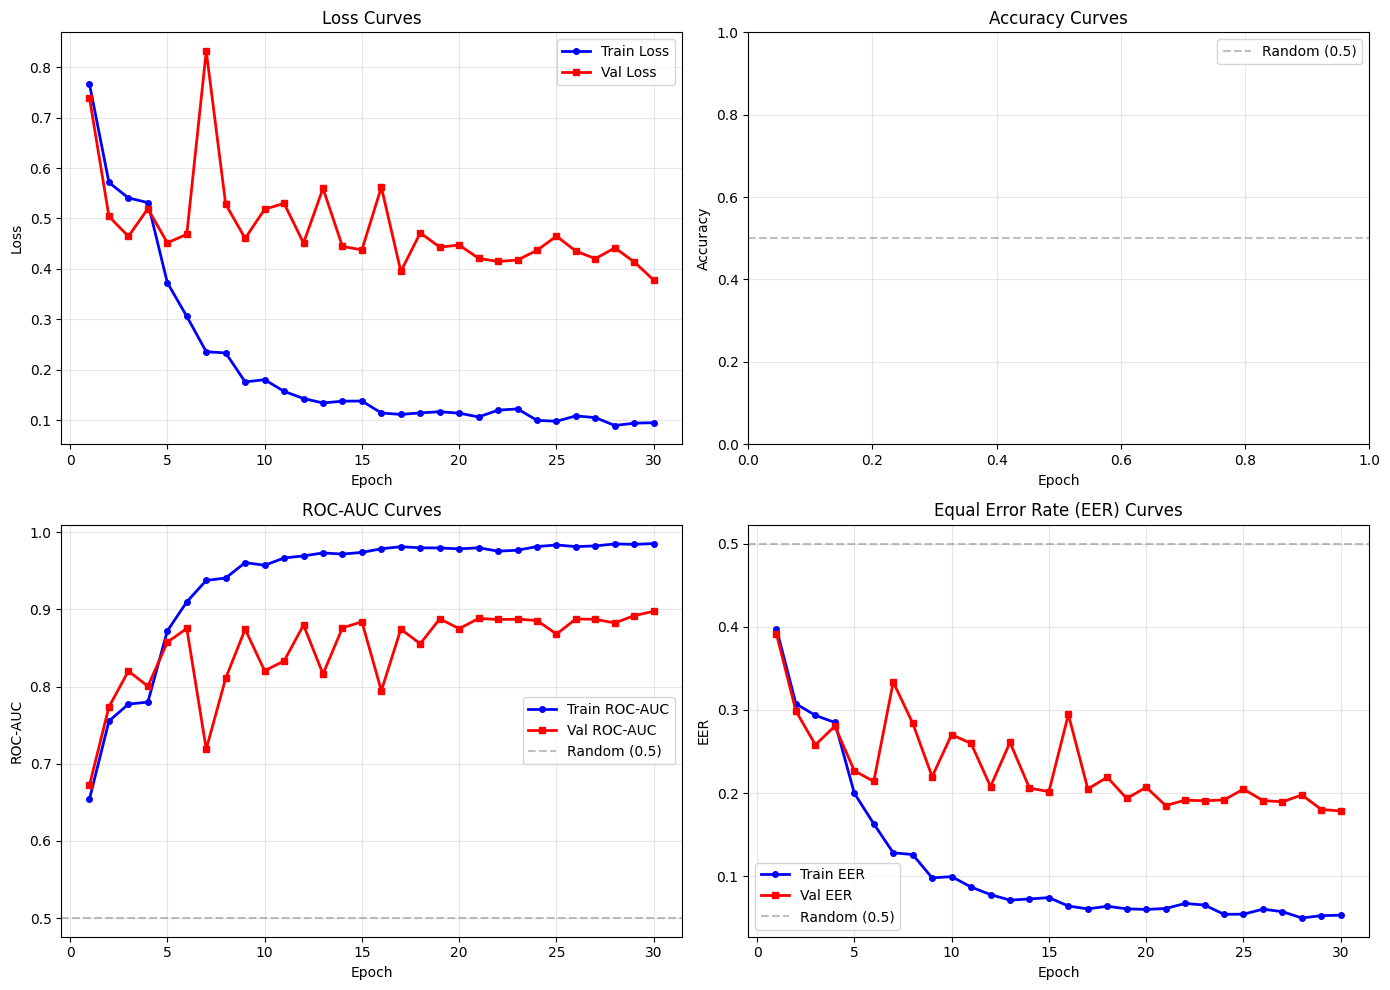

In [35]:
epochs = range(1, len(history_agr_freezed['train_loss']) + 1)

train_loss = history_agr_freezed['train_loss']
val_loss = history_agr_freezed['val_loss']
train_roc_auc = history_agr_freezed['train_roc_auc']
val_roc_auc = history_agr_freezed['val_roc_auc']
train_eer = history_agr_freezed['train_eer']
val_eer = history_agr_freezed['val_eer']
lr = history_agr_freezed['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[1, 0].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_freezed_agr.png', dpi=150, bbox_inches='tight')
plt.show()

Now ler's test on test set

In [15]:
def evaluate_model(model, test_loader, device, threshold=0.5):
    """
    Evaluate Siamese network on test set (pair-based).

    Args:
        model: trained Siamese network (forward returns two embeddings for img1, img2)
        test_loader: DataLoader yielding (img1, img2, label) pairs
        device: torch device
        threshold: threshold on Euclidean distance for classification (distance <= threshold -> same author)

    Returns:
        dict: {
            'roc_auc': float,
            'eer': float,
            'accuracy': float,
            'mean_pos_distance': float,
            'mean_neg_distance': float
        }
    """
    model.eval()
    all_labels = []
    all_distances = []

    with torch.no_grad():
        for img1, img2, labels in test_loader:
            img1 = img1.to(device)
            img2 = img2.to(device)

            # Get embeddings for both images
            emb1 = model.forward_one(img1)
            emb2 = model.forward_one(img2)

            # Compute Euclidean distance
            distances = torch.norm(emb1 - emb2, p=2, dim=1).cpu().numpy()

            all_labels.extend(labels.numpy())
            all_distances.extend(distances)

    labels = np.array(all_labels)
    distances = np.array(all_distances)

    # ROC-AUC (use negative distances because smaller distance = more similar)
    roc_auc = roc_auc_score(labels, -distances)

    # EER
    scores = -distances
    fpr, tpr, _ = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

    # Accuracy with given threshold
    pred = (distances <= threshold).astype(int)
    accuracy = (pred == labels).mean()

    # Mean distances per class
    mean_pos = distances[labels == 1].mean() if np.any(labels == 1) else 0.0
    mean_neg = distances[labels == 0].mean() if np.any(labels == 0) else 0.0

    return {
        'roc_auc': roc_auc,
        'eer': eer,
        'accuracy': accuracy,
        'mean_pos_distance': mean_pos,
        'mean_neg_distance': mean_neg
    }

In [17]:
checkpoint = torch.load('best_model_triplet.pth', map_location='cpu', weights_only=False)

In [18]:

model = SiameseNetwork(embedding_size=256, freeze_mode=None)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 117MB/s]


Freeze mode: None
Total parameters: 25,862,336
Trainable parameters: 25,862,336 (100.0%)


SiameseNetwork(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [19]:
model=model.to(device)

In [26]:
result = evaluate_model(model, test_loader, device)



In [27]:
result

{'roc_auc': np.float64(0.900090066906845),
 'eer': np.float64(0.18997683993823986),
 'accuracy': np.float64(0.809),
 'mean_pos_distance': np.float32(0.3010755),
 'mean_neg_distance': np.float32(1.1213148)}

Now let's train the model without freezing and compare results

Now let's test our model on separate datasets, ICDAR (dutch and chinese parts separately) and CVL.
First we create fixed pairs from these datasets to reuse the same dataset on all models

In [56]:
file_id = "1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk"
output_name = "icdar_chinese.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk
From (redirected): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk&confirm=t&uuid=0df05d44-7321-4377-a04b-256fe7859a91
To: /content/icdar_chinese.zip
100% 405M/405M [00:06<00:00, 62.4MB/s]


In [57]:
with zipfile.ZipFile("icdar_chinese.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3']

In [58]:

file_id = "1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO"
output_name = "icdar_chinese_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO
To: /content/icdar_chinese_pairs.pkl
100% 123k/123k [00:00<00:00, 73.8MB/s]


In [59]:
DATA_ROOT_icdar_chinese = "/kaggle/working/icdar_chinese_pairs.pkl"

In [60]:
test_icdar_chinese_dataset = SavedTestPairsDataset("icdar_chinese_pairs.pkl", transform=test_transform)

In [61]:
test_icdar_chinese_loader = DataLoader(
    dataset=test_icdar_chinese_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [62]:

file_id = "1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK"
output_name = "icdar_dutch.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK
From (redirected): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK&confirm=t&uuid=db1e28b9-d662-477b-98fb-dec011b32800
To: /content/icdar_dutch.zip
100% 388M/388M [00:04<00:00, 84.4MB/s]


In [63]:
with zipfile.ZipFile("icdar_dutch.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'icdar_dutch', 'all_data_3']

In [64]:
file_id = "1glxrUV2kPnFy8QV83GaouOVLLkl37SnM"
output_name = "icdar_dutch_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1glxrUV2kPnFy8QV83GaouOVLLkl37SnM
To: /content/icdar_dutch_pairs.pkl
100% 178k/178k [00:00<00:00, 87.5MB/s]


In [65]:
DATA_ROOT_icdar_dutch = "/kaggle/working/icdar_dutch_pairs.pkl"

In [66]:
test_icdar_dutch_dataset = SavedTestPairsDataset("icdar_dutch_pairs.pkl", transform=test_transform)

In [67]:
test_icdar_dutch_loader = DataLoader(
    dataset=test_icdar_dutch_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [68]:
file_id = "17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ"
output_name = "cvl.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ
From (redirected): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ&confirm=t&uuid=49c50ff6-ffcc-40d9-9a6e-3d9db6d19aae
To: /content/cvl.zip
100% 277M/277M [00:04<00:00, 64.5MB/s]


In [69]:
with zipfile.ZipFile("cvl.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'icdar_dutch', 'cvl', 'all_data_3']

In [70]:
file_id = "1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu"
output_name = "cvl_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu
To: /content/cvl_pairs.pkl
100% 171k/171k [00:00<00:00, 102MB/s]


In [71]:
DATA_ROOT_cvl = "/kaggle/working/cvl_pairs.pkl"

In [72]:
test_cvl_dataset = SavedTestPairsDataset('cvl_pairs.pkl', transform=test_transform)

In [73]:
test_cvl_loader = DataLoader(
    dataset=test_cvl_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [76]:
result_icdar_chinese = evaluate_model(
        model=model,
        test_loader=test_icdar_chinese_loader,
        device=device
    )


In [77]:
result_icdar_chinese

{'roc_auc': np.float64(0.5663086142367646),
 'eer': np.float64(0.46200204791886923),
 'accuracy': np.float64(0.4962),
 'mean_pos_distance': np.float32(0.07057924),
 'mean_neg_distance': np.float32(0.08661933)}

In [80]:
result_icdar_dutch =evaluate_model(
        model=model,
        test_loader=test_icdar_dutch_loader,
        device=device
    )


In [81]:
result_icdar_dutch

{'roc_auc': np.float64(0.6791737222573533),
 'eer': np.float64(0.3796016706613643),
 'accuracy': np.float64(0.6226),
 'mean_pos_distance': np.float32(0.39592838),
 'mean_neg_distance': np.float32(0.69303125)}

In [82]:
result_cvl =evaluate_model(
        model=model,
        test_loader=test_cvl_loader,
        device=device
    )

In [84]:
result_cvl

{'roc_auc': np.float64(0.5940183908664118),
 'eer': np.float64(0.43039851572148263),
 'accuracy': np.float64(0.5196),
 'mean_pos_distance': np.float32(0.09847046),
 'mean_neg_distance': np.float32(0.13109423)}